In [20]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

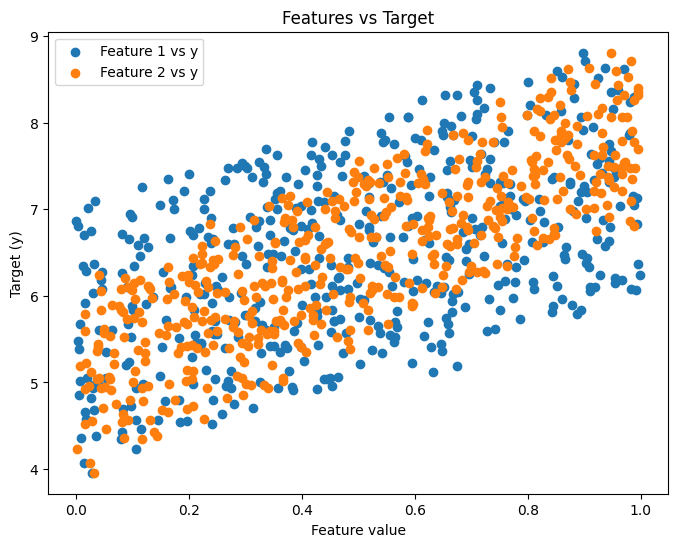

In [21]:
X = np.random.rand(500, 2)
y = 4 + 2 * X[:, 0] + 3 * X[:, 1] + np.random.randn(500) * 0.1 # is in a single row, we want column

y = y.reshape(-1, 1)

# plt.style.use('dark_background')
fig = plt.figure(figsize=(8,6))

plt.scatter(X[:, 0], y, label="Feature 1 vs y")
plt.scatter(X[:, 1], y, label="Feature 2 vs y")

plt.xlabel("Feature value")
plt.ylabel("Target (y)")
plt.title("Features vs Target")

plt.legend()
plt.show()

In [22]:
def hypothesis(X, w, b):
    return np.dot(X,w) + b

In [23]:
def loss(y, y_pred):
    n = len(y)

    return (1/n) * np.sum((y-y_pred) ** 2)

In [24]:
def gradient(X, y, y_pred):
    n = len(y)

    dw = (-2/n) * np.dot(X.T, (y-y_pred))
    db = (-2/n) * np.sum(y-y_pred)

    return dw, db

In [25]:
w = np.zeros((X.shape[1], 1)) # because we don't have only one feature this time, we have two features.
b = 0
learning_rate = 0.001
epochs = 3000

for i in range(epochs):
    y_pred = hypothesis(X,w,b)
    model_loss = loss(y, y_pred)

    dw, db = gradient(X, y, y_pred)

    w = w - learning_rate*dw
    b = b - learning_rate*db

    if (i % 100 == 0):
        print(f"Iteration {i}, Loss: {model_loss}")

Iteration 0, Loss: 43.163655993846156
Iteration 100, Loss: 23.460939112038876
Iteration 200, Loss: 12.763191071158245
Iteration 300, Loss: 6.954460121616891
Iteration 400, Loss: 3.800105659828604
Iteration 500, Loss: 2.08689189099505
Iteration 600, Loss: 1.1561259552782597
Iteration 700, Loss: 0.6501884508025232
Iteration 800, Loss: 0.37491933504638736
Iteration 900, Loss: 0.224904233671969
Iteration 1000, Loss: 0.14291075008926152
Iteration 1100, Loss: 0.09786555398278378
Iteration 1200, Loss: 0.07289766244492467
Iteration 1300, Loss: 0.05884687626818622
Iteration 1400, Loss: 0.050739367988277294
Iteration 1500, Loss: 0.04587420123875599
Iteration 1600, Loss: 0.04278445981142543
Iteration 1700, Loss: 0.04067322139023569
Iteration 1800, Loss: 0.0391073348179818
Iteration 1900, Loss: 0.037851164534244246
Iteration 2000, Loss: 0.036776326257570956
Iteration 2100, Loss: 0.03581267998754547
Iteration 2200, Loss: 0.034921722522305125
Iteration 2300, Loss: 0.03408214117828767
Iteration 2400,

In [26]:
w, b

(array([[2.09560923],
        [2.51822828]]),
 np.float64(4.198420439984571))

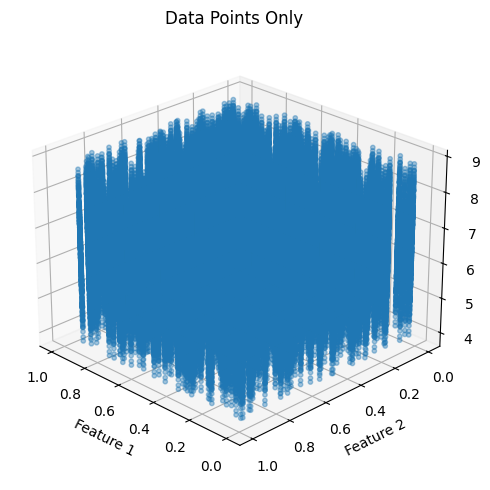

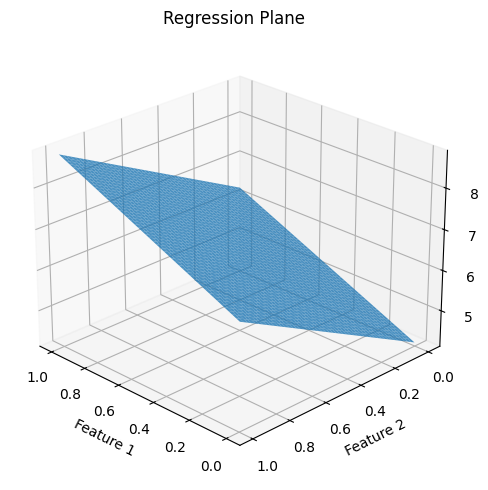

In [31]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Optional: downsample if too large
max_points = 3000
if len(X) > max_points:
    idx = np.random.choice(len(X), max_points, replace=False)
    X_plot = X[idx]
    y_plot = y[idx]
else:
    X_plot = X
    y_plot = y

ax.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    y_plot,
    alpha=0.4,
    s=10
)

ax.set_title("Data Points Only")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")

ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()

# for regression plane
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Mesh grid
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Plane equation
y_pred_grid = w[0] * x1_grid + w[1] * x2_grid + b

# Surface plot
ax.plot_surface(
    x1_grid,
    x2_grid,
    y_pred_grid,
    alpha=0.8
)

ax.set_title("Regression Plane")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Predicted Target")

ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()